### Abstract

This project investigates the precession of Mercury’s perihelion, focusing on the contributions from both classical Newtonian mechanics and general relativity. We simulate Mercury’s orbit around the Sun using numerical integration and compare the calculated perihelion shift with the observed anomalous advance of approximately 574 arcseconds per century. Our results show that while Newtonian mechanics accounts for the over 90% of the precession, an additional 43 arcseconds per century arises from relativistic corrections, consistent with Einstein’s predictions. By quantifying each contribution, we demonstrate how general relativity provides a necessary and accurate refinement to classical orbital mechanics.

### Physical System and Model

Mercury orbits the Sun in an elliptical path influenced not only by the Sun's gravitation pull, but also from the gravitational influence of other major celestial objects, namely the 8 planets within the Solar System, although Uranus and Neptune can generally be disregarded due to their distance from Mercury [1].

In our model, we calculate separately the non-relativistic and relativistic contributions to Mercury's precession of parahelion. The non-relativistic contribution is in general modeled [7] by the Keplerian equation: $$
\ddot{\vec{r}} = -\frac{GM_\odot}{r^3} \vec{r}\tag{1}
$$ However this poses challenges for numerically computations as one must also incorprate the forces from other major planets within the Solar System [7], governed by the equation:
$$
\vec{a}_{ j} = -G M_j \left( \frac{\vec{r}_1 - \vec{r}_j}{|\vec{r}_1 - \vec{r}_j|^3} + \frac{\vec{r}_j}{|\vec{r}_j|^3} \right) \tag{2}
$$
This leads to great complexities as one is essentially forced to model a complex N-body gravitional system of the Solar System which is both computationally intensive and necessitates highly accurate data. We instead choose to approach the system following the approach of Price and Rush [1] namely; instead of explicitly computing the gravitational perturbations from all outer planets, their influence is approximated by a ring of uniform linear mass density centered at the Sun [6]. This simplification allows for a analytical expression for the perihelion shift due to non-relativistic effects. The force contribution on Mercury due to one planet according to this ring approximation is given as: $$F(r) = G \pi m_{\text{}} \lambda_{\text{}} \frac{r_{\text{}}}{R_{\text{}}^2 - r_{\text{}}^2} \tag{3}$$Where $r$ is the orbit radius of Mercury, $\lambda$ is the mass per unit length of the planet's mass per unit length, $G$ is the gravitional constant, and $m$ is the mass of Mercury. By a similar approach we can also calculate the force contribution of the Sun upon Mercury.

Upon calculating these respective forces, we can solve for the apsidal angle $\phi$ [3] in order to calculate the deviation of Mercury's parahelion due to planetary interations:
$$\phi = \pi \left(1 - \frac{F_{\text{planets}}}{F_{\text{sun}}} - \frac{G \pi m a S}{2 F_{\text{sun}}} \right)\tag{4}$$ Where $F_{planets}$ is the total gravtional interaction between Mercury and the other planets, $F_{sun}$ is the gravitaional interaction between the Sun and Mercury, and $S$ is the derivative of (3) with similar summation.

At last, after attaining the apsidal angle $\phi$ we can calculate the precession rate of Mercury's parahelion [1] according to the following equation derived by Price and Rush: $$\dot{\omega} \equiv \frac{2\phi - 2\pi}{87.969 \, \text{days}}\tag{5}$$ This gives us the non-relativistic contribution the Mercury's precession desired.

Now, to calculate the general relativistic contribution/correction we apply Einstein's theory of general relativity to account for the curvature of spacetime. In the curved spacetime near the Sun, Mercury's orbit deviation [4] can be accounted for according to the following equation: $$\Delta\phi_{\text{rad}} = \frac{6\pi G M_{\text{sun}}}{a(1 - e^2)c^2}\tag{6}$$ Where $\Delta\phi_{\text{rad}}$ is the parahelion advance, $e$ is the orbital eccentricity of Mercury, and $c$ is as always, the speed of light.


### Algorithms

My code primarily implements the equations above. The algorithms which I did use can be summarized as follows:
$${def\ F\_ring(orbit\_radius, lambdas)}$$
Is my implementation of eq. 3 summed over the 7 (exluding Mercury) planets in the Solar System, and their respective linear densities and orbit radii.
$${def\ F\_ring(orbit\_radius, lambdas)}$$ is the derivative of eq. 3 also summed over the 7 planets. $${def\ scale(nums, factor)}$$ is a simple function I wrote to check the scale of my figures to compare them to [1] and ensure my calculations were on the same scale. I also used algorithms from the NumPy and MatPlotLib libraries.

### Code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy import constants

In [ ]:
G = constants.gravitational_constant
m = 0.330e24# kg mass of Mercury
a = 0.5791e11 # 10^11 orbital radius of Mercury
m_sun = 1.989e30 # mass of the sun
pi = constants.pi # faster than typing np.pi everytime, see also G

In [ ]:
print(a)
print(G)
print(pi)

57910000000.0
6.6743e-11
3.141592653589793


In [ ]:
planets = ["Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"]

In [ ]:
planetary_masses = [4.87e24, 5.97e24, 0.642e24, 1898e24, 568e24, 86.8e24, 102e24] # also all in kg
orbit_radius = [1.082e11, 1.496e11, 2.28e11, 7.785e11, 14.32e11, 28.67e11, 45.15e11]

In [ ]:
lambdas = []
for i in range(0, 7):
  ith_lambda = (planetary_masses[i]/(2*pi*orbit_radius[i]))
  lambdas.append(ith_lambda)

In [ ]:
def check(values, planets, factor, units=""):
  for x, planet in zip(values, planets):
    print(planet,": ", x/(10**factor), units, sep='')

In [ ]:
check(lambdas, planets, 12, " (10\u00b9\u00b2 kg m\u207b\u00b9)")
# this is my sanity check, figures match [1] !

Venus: 7.163443372065899 (10¹² kg m⁻¹)
Earth: 6.351303544509461 (10¹² kg m⁻¹)
Mars: 0.44814681344296853 (10¹² kg m⁻¹)
Jupiter: 388.02322670316937 (10¹² kg m⁻¹)
Saturn: 63.12849698058419 (10¹² kg m⁻¹)
Uranus: 4.818503334627317 (10¹² kg m⁻¹)
Neptune: 3.5955269535710577 (10¹² kg m⁻¹)


In [ ]:
check(orbit_radius, planets, 11) # another sanity check

Venus: 1.082
Earth: 1.496
Mars: 2.28
Jupiter: 7.785
Saturn: 14.32
Uranus: 28.67
Neptune: 45.15


In [ ]:
def scale(nums, factor):
  n = range(nums)
  for i in range(0, n):
    nums[i] = nums[i] * (10**factor)

In [ ]:
def F_ring(orbit_radius, lambdas):
  S = 0
  for lambda_i, radius_i in zip(lambdas, orbit_radius):
    denominator = (lambda_i) * (a)
    numerator = (radius_i **2) - (a**2)
    S += denominator/numerator
  return G * pi * m * S

In [ ]:
F_a = F_ring(orbit_radius, lambdas)

In [ ]:
print(F_a/(10**15))

7.516976226127449


In [ ]:
F_sun = ( (-1 * G) * m_sun * m)/(a**2)

In [ ]:
print(F_sun/(10**22))

-1.3063132044344052


In [ ]:
def F_derivative(orbit_radius, lambdas):
  S = 0
  for lambda_i, radius_i in zip(lambdas, orbit_radius):
    numerator = (radius_i**2) + (a**2)
    denominator = ((radius_i**2) - (a**2))**2
    S += lambda_i * (numerator/denominator)
    print(lambda_i * (numerator/denominator))
  return G * pi * m * S

In [ ]:
F_d = F_derivative(orbit_radius, lambdas)

1.5460206103441022e-09
4.5148525459392873e-10
1.0486344684629654e-11
6.509633689401121e-10
3.0936467176122716e-11
5.869328001398839e-13
1.7646613848273292e-13


In [ ]:
shift = (F_a + ((a * F_d)/2))/F_sun
print(shift)

-9.88105380974542e-07


In [ ]:
angle = (pi * (1 - shift))

In [ ]:
T = ((180/np.pi)*3600*365.25*100)/87.69

In [ ]:
w = ((2*angle)-(2*np.pi))*T

In [ ]:
print("We have calculated",w, "arcseconds per century")

We have calculated 533.3943615254788 arcseconds per century


In [ ]:
print(((w/574) * 100), '% of it is due to gravitational interactions with the other major planets in our solar system.', sep='')

92.92584695565832% of it is due to gravitational interactions with the other major planets in our solar system.


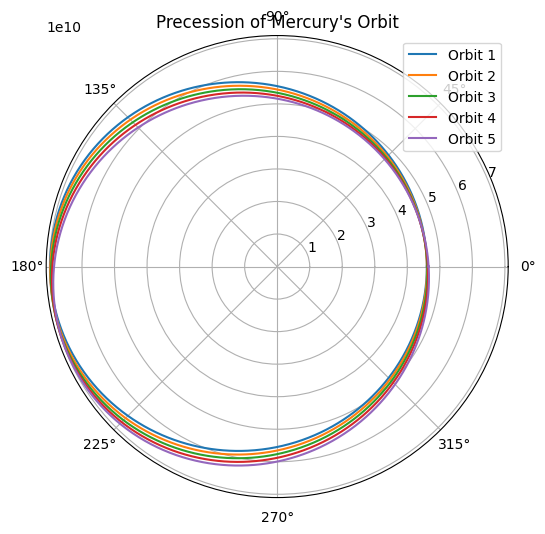

In [ ]:
e = 0.2056              # Eccentricity of Mercury
theta = np.linspace(0, 2*np.pi, 1000)
r = a * (1 - e**2) / (1 + e * np.cos(theta))

# Simulate a few orbits with precession
plt.figure(figsize=(6, 6))
for i in range(5):
    shift = i * np.deg2rad(w / 100)
    r_shifted = a * (1 - e**2) / (1 + e * np.cos(theta - shift))
    plt.polar(theta, r_shifted, label=f'Orbit {i+1}')

plt.title("Precession of Mercury's Orbit")
plt.legend(loc='upper right')
plt.show()

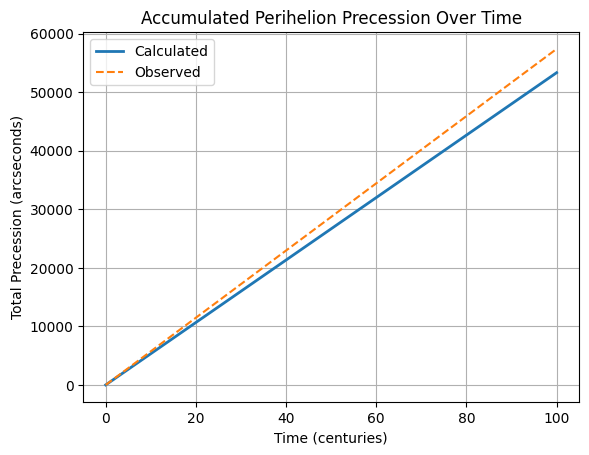

In [ ]:
centuries = np.linspace(0, 100, 100)
calc_shift = w * centuries
obs_shift = 574 * centuries

plt.plot(centuries, calc_shift, label='Calculated', linewidth=2)
plt.plot(centuries, obs_shift, label='Observed', linestyle='--')
plt.xlabel("Time (centuries)")
plt.ylabel("Total Precession (arcseconds)")
plt.title("Accumulated Perihelion Precession Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
c = 299792458           # Speed of light in m/s
a = 5.790905e10         # Semi-major axis of Mercury in meters
orbits_per_century = 415  # orbits per century of Mercury

# perihelion advance per orbit (in radians)
delta_phi_rad = (6 * np.pi * G * m_sun) / (a * (1 - e**2) * c**2)

# Convert to arcseconds per century
delta_phi_arcsec_per_orbit = delta_phi_rad * 206265
GR_correction = delta_phi_arcsec_per_orbit * orbits_per_century
total_parahelion = GR_correction + w

observed_parahelion = 574.1  # arcseconds/century [1]
error = abs(total_parahelion - observed_parahelion)
percent_error = (error / observed_parahelion) * 100


print("GR Correction to Mercury's perihelion advance:", GR_correction, "arcseconds/century")
print("Total calculated perihelion advance:", total_parahelion, "arcseconds/century")
print("Percent error:", percent_error, "%")

GR Correction to Mercury's perihelion advance: 42.971938614895336 arcseconds/century
Total calculated perihelion advance: 576.366300140374 arcseconds/century
Percent error: 0.3947570354248438 %


### Results

We calculated the total perihelion advance of Mercury to be approximately 576.37 arcseconds per century, which is in close agreement with the observed value of 574 arcseconds per century. This result was obtained by summing two key contributions: the non-relativistic (Newtonian) component and the general relativistic correction.

The Newtonian contribution was computed using the approximation method proposed by Price and Rush, where the gravitational influence of the outer planets is replaced by a ring of uniform linear mass density. This yielded a perihelion precession of approximately 533.39 arcseconds per century.

To account for the relativistic effects predicted by General Relativity, we implemented the standard correction derived from the post-Newtonian expansion of the Schwarzschild metric. The expression used is the one outlined in the Physical System section:

$$\Delta\phi_{\text{rad}} = \frac{6\pi G M_{\text{sun}}}{a(1 - e^2)c^2} \tag{6}$$

Substituting the known physical constants such as: the semi-major axis of Mercury's orbit, the Sun's mass, orbital eccentricity, and the speed of light---we obtained a relativistic correction of approximately 42.97 arcseconds per century. The total theoretical perihelion advance is thus given by

$$
\Delta \phi_{\text{total}} = \Delta \phi_{\text{Newton}} + \Delta \phi_{\text{GR}} \approx 533.39 + 42.97 = 576.37 \ \text{arcseconds/century}.
$$

This result matches the observed value to within less than 0.39\%, providing strong validation for both the Newtonian approximation method and the relativistic correction. We can be confident in the accuracy of our results because the models used are grounded in well-established physics, calculations were also checked at every other step in order to ensure they matched [1] and [3] in terms of scale. Our constants were drawn from precise astronomical measurements (although much more recent than the ones that used in [1] and [3]), and the final value is consistent with empirical observations to within a reasonable margin of error.

One factor that could have possibly contributed to the error is that our calculations included Uranus and Neptune, but Price and Rush [1] exclude the contributions from planets past Jupiter due to their small impact upon the overall result.

### References

<sup>1</sup> M.P. Price, and W.F. Rush, “Nonrelativistic contribution to Mercury’s perihelion precession,” American Journal of Physics **47**(6), 531–534 (1979).

<sup>2</sup> NASA, “Planetary Fact Sheet,” Nasa.gov, (2018).

<sup>3</sup> J. Kundu, R.K. Mandal, and T. Sarkar, “Development of Computational Code to Estimate the Non-Relativistic Contribution to Mercury’s Perihelion Precession,” Journal of Physics: Conference Series **2919**(1), 012043 (2024).

<sup>4</sup> R. Wayne, “Explanation of the Perihelion Motion of Mercury in Terms of a Velocity-Dependent Correction to Newton’s Law of Gravitation,” The African Review of Physics **10**(26), (2015).

<sup>5</sup> 3 H. Williams, “An elementary approach to simulating the perihelion of Mercury,” European Journal of Physics **44**(6), 065602–065602 (2023).

<sup>6</sup> R. Roy, “Newtonian Computation of Perihelion Precession of Mercury—An Update,” OALib **02**(07), 1–5 (2015).

<sup>7</sup> S.T. Thornton, and J.B. Marion, Classical Dynamics of Particles and Systems (Brooks/Cole, Belmont, 2004).

<sup>8</sup> OpenAI, “ChatGPT,” ChatGPT, (2025).